# Messy Mashup — Exploratory Data Analysis
**Music Genre Classification from Noisy Mashups**

In [3]:
import os, glob, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import librosa, librosa.display

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DATA_ROOT = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_DIR = os.path.join(DATA_ROOT, 'genres_stems')
NOISE_DIR = os.path.join(DATA_ROOT, 'ESC-50-master', 'audio')
TEST_DIR  = os.path.join(DATA_ROOT, 'mashups')
TEST_CSV  = os.path.join(DATA_ROOT, 'test.csv')
NOISE_CSV = os.path.join(DATA_ROOT, 'ESC-50-master', 'meta', 'esc50.csv')

GENRES = sorted(['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock'])
STEMS  = ['drums', 'vocals', 'bass', 'others']
SR = 22050

## 1. Dataset Overview

In [4]:
# Count songs and stems per genre
rows = []
for genre in GENRES:
    gp = os.path.join(STEMS_DIR, genre)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for song in songs:
        for st in STEMS:
            exists = os.path.exists(os.path.join(gp, song, f"{st}.wav"))
            rows.append({'genre': genre, 'song': song, 'stem': st, 'exists': exists})

df = pd.DataFrame(rows)
missing = df[~df['exists']]

test_files = glob.glob(os.path.join(TEST_DIR, '*.wav'))
esc_meta = pd.read_csv(NOISE_CSV)

print(f"Training: {df.groupby('genre')['song'].nunique().iloc[0]} songs × {len(GENRES)} genres = {df['song'].nunique()} songs")
print(f"Stems per song: {STEMS}")
print(f"Missing stems: {len(missing)} ({missing['stem'].value_counts().to_dict()})")
print(f"Test mashups: {len(test_files)}")
print(f"ESC-50 noise: {len(esc_meta)} clips, {esc_meta['category'].nunique()} categories")

Training: 100 songs × 10 genres = 1000 songs
Stems per song: ['drums', 'vocals', 'bass', 'others']
Missing stems: 1000 ({'others': 1000})
Test mashups: 3020
ESC-50 noise: 2000 clips, 50 categories


## 2. Class Distribution

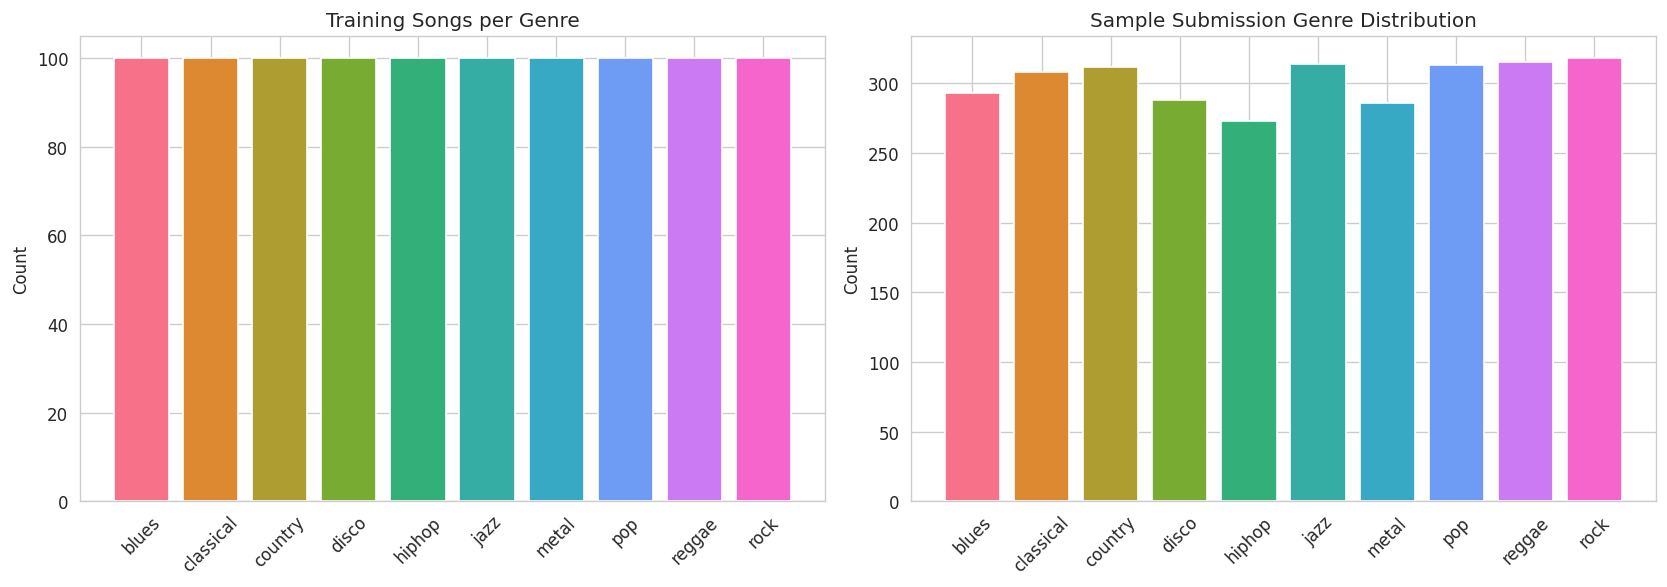

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
songs_per_genre = df.groupby('genre')['song'].nunique()
axes[0].bar(songs_per_genre.index, songs_per_genre.values, color=sns.color_palette('husl', 10))
axes[0].set_title('Training Songs per Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Test predictions distribution (from sample submission)
sample_sub = pd.read_csv(os.path.join(DATA_ROOT, 'sample_submission.csv'))
test_dist = sample_sub['genre'].value_counts().sort_index()
axes[1].bar(test_dist.index, test_dist.values, color=sns.color_palette('husl', 10))
axes[1].set_title('Sample Submission Genre Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Stem Availability
The `others` stem is missing for **all** songs — only drums, vocals, and bass are available.

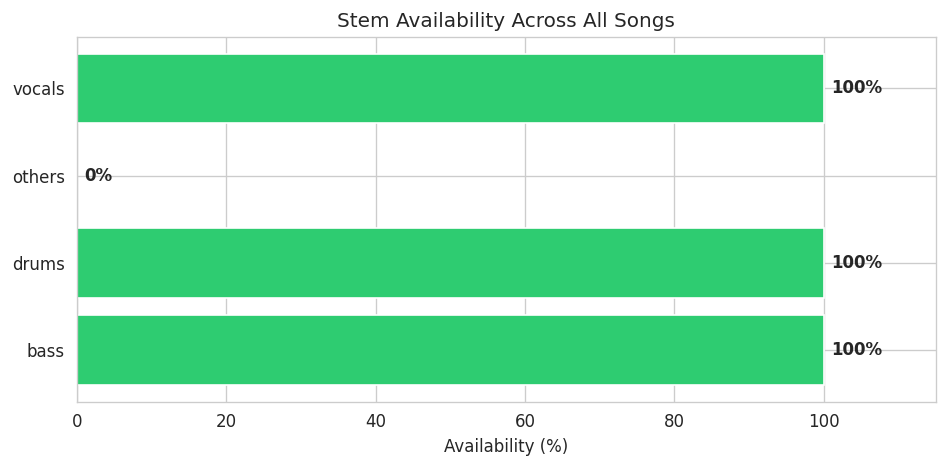

In [6]:
stem_avail = df.groupby('stem')['exists'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if v == 100 else '#e74c3c' for v in stem_avail.values]
ax.barh(stem_avail.index, stem_avail.values, color=colors)
ax.set_xlabel('Availability (%)')
ax.set_title('Stem Availability Across All Songs')
for i, v in enumerate(stem_avail.values):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontweight='bold')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig('stem_availability.png', bbox_inches='tight')
plt.show()

## 4. Audio Statistics per Genre

In [7]:
stats = []
for genre in GENRES:
    gp = os.path.join(STEMS_DIR, genre)
    songs = sorted(os.listdir(gp))[:20]  # sample 20 songs
    for song in songs:
        song_dir = os.path.join(gp, song)
        if not os.path.isdir(song_dir): continue
        for st in ['drums', 'vocals', 'bass']:
            fp = os.path.join(song_dir, f"{st}.wav")
            if not os.path.exists(fp): continue
            y, _ = librosa.load(fp, sr=SR, duration=10.0)
            rms = float(np.mean(librosa.feature.rms(y=y)))
            sc = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=SR)))
            zcr = float(np.mean(librosa.feature.zero_crossing_rate(y)))
            stats.append({'genre': genre, 'stem': st, 'rms': rms,
                         'spectral_centroid': sc, 'zcr': zcr})

stats_df = pd.DataFrame(stats)
print(f"Computed stats for {len(stats_df)} stem files")

Computed stats for 600 stem files


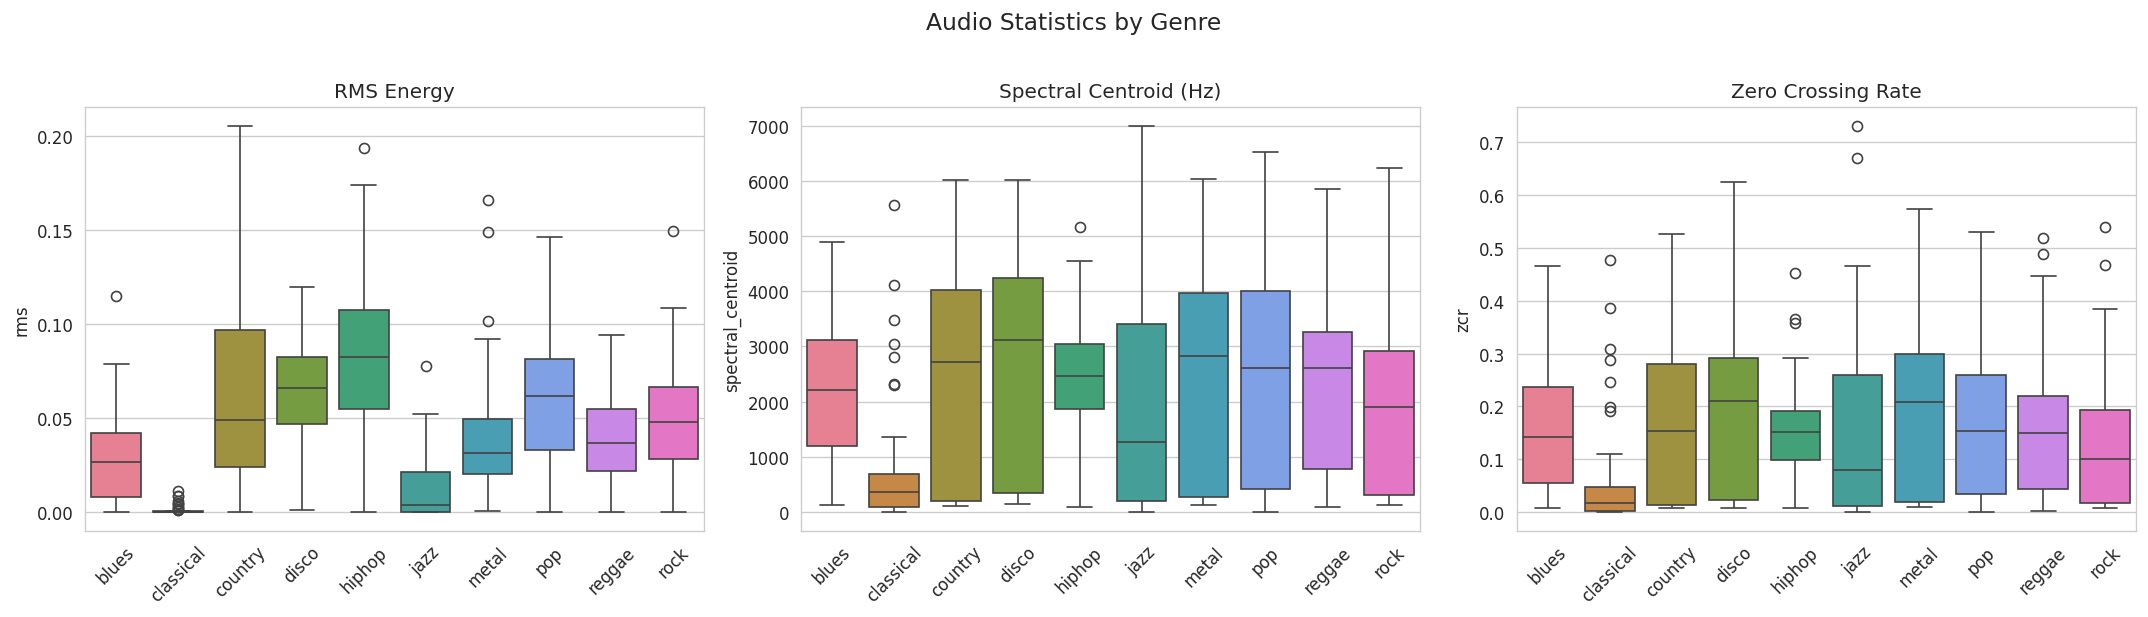

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, title) in enumerate([('rms', 'RMS Energy'), ('spectral_centroid', 'Spectral Centroid (Hz)'), ('zcr', 'Zero Crossing Rate')]):
    sns.boxplot(data=stats_df, x='genre', y=col, ax=axes[i], palette='husl')
    axes[i].set_title(title)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
plt.suptitle('Audio Statistics by Genre', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('audio_stats_boxplot.png', bbox_inches='tight')
plt.show()

## 5. Per-Stem Genre Profiles
Which stems carry the most genre information?

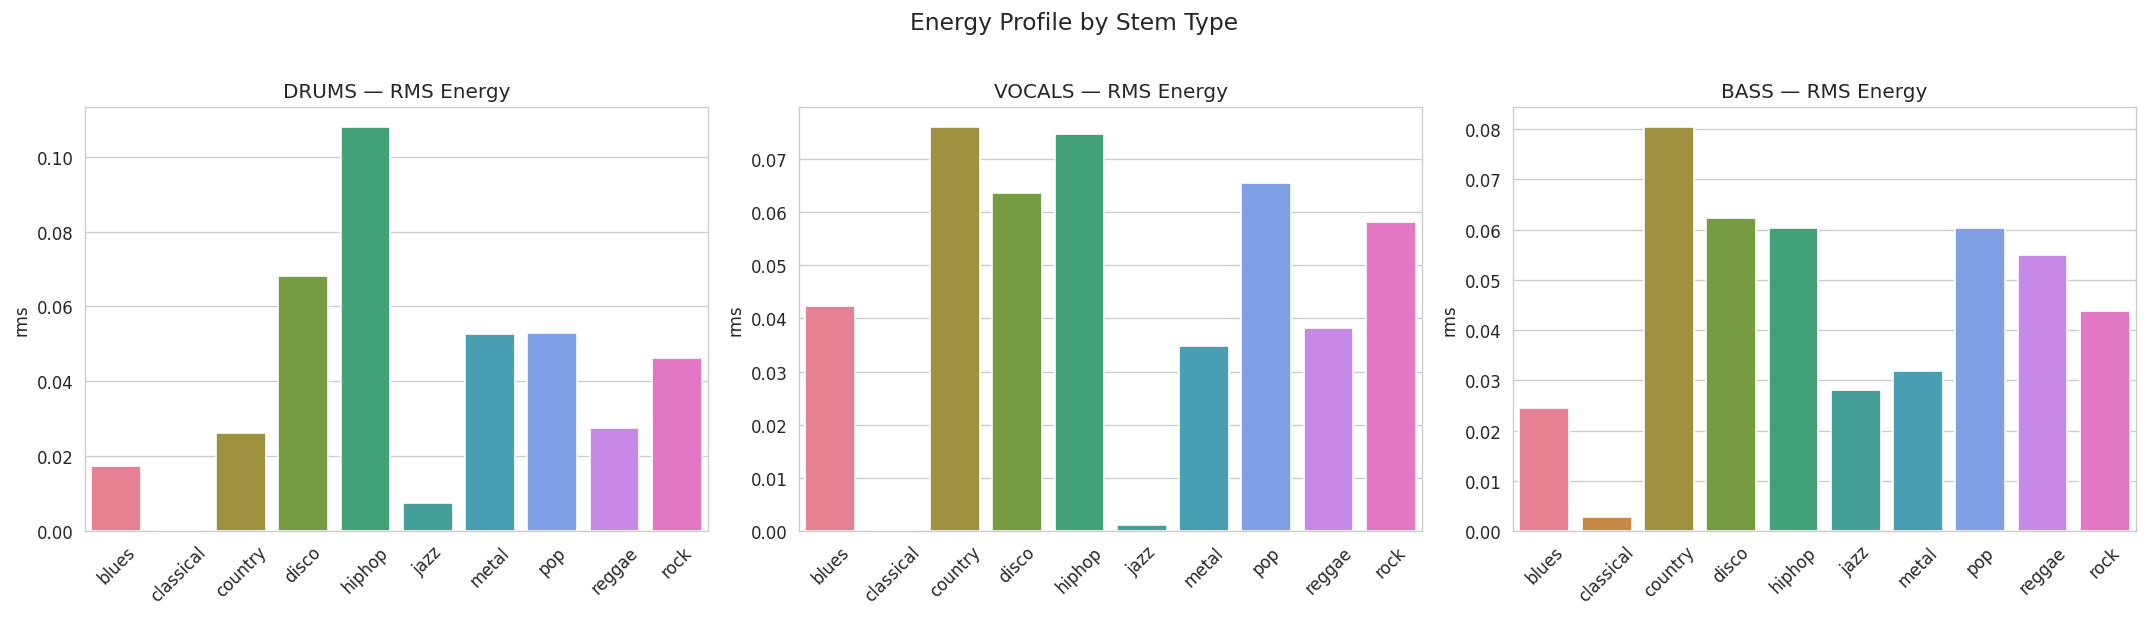

Key finding: Classical/Jazz have very low energy — model must be volume-invariant.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, st in enumerate(['drums', 'vocals', 'bass']):
    sub = stats_df[stats_df['stem'] == st]
    sns.barplot(data=sub, x='genre', y='rms', ax=axes[i], palette='husl', ci=None)
    axes[i].set_title(f'{st.upper()} — RMS Energy')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
plt.suptitle('Energy Profile by Stem Type', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('stem_profiles.png', bbox_inches='tight')
plt.show()
print("Key finding: Classical/Jazz have very low energy — model must be volume-invariant.")

## 6. Mel Spectrograms — Train vs Test

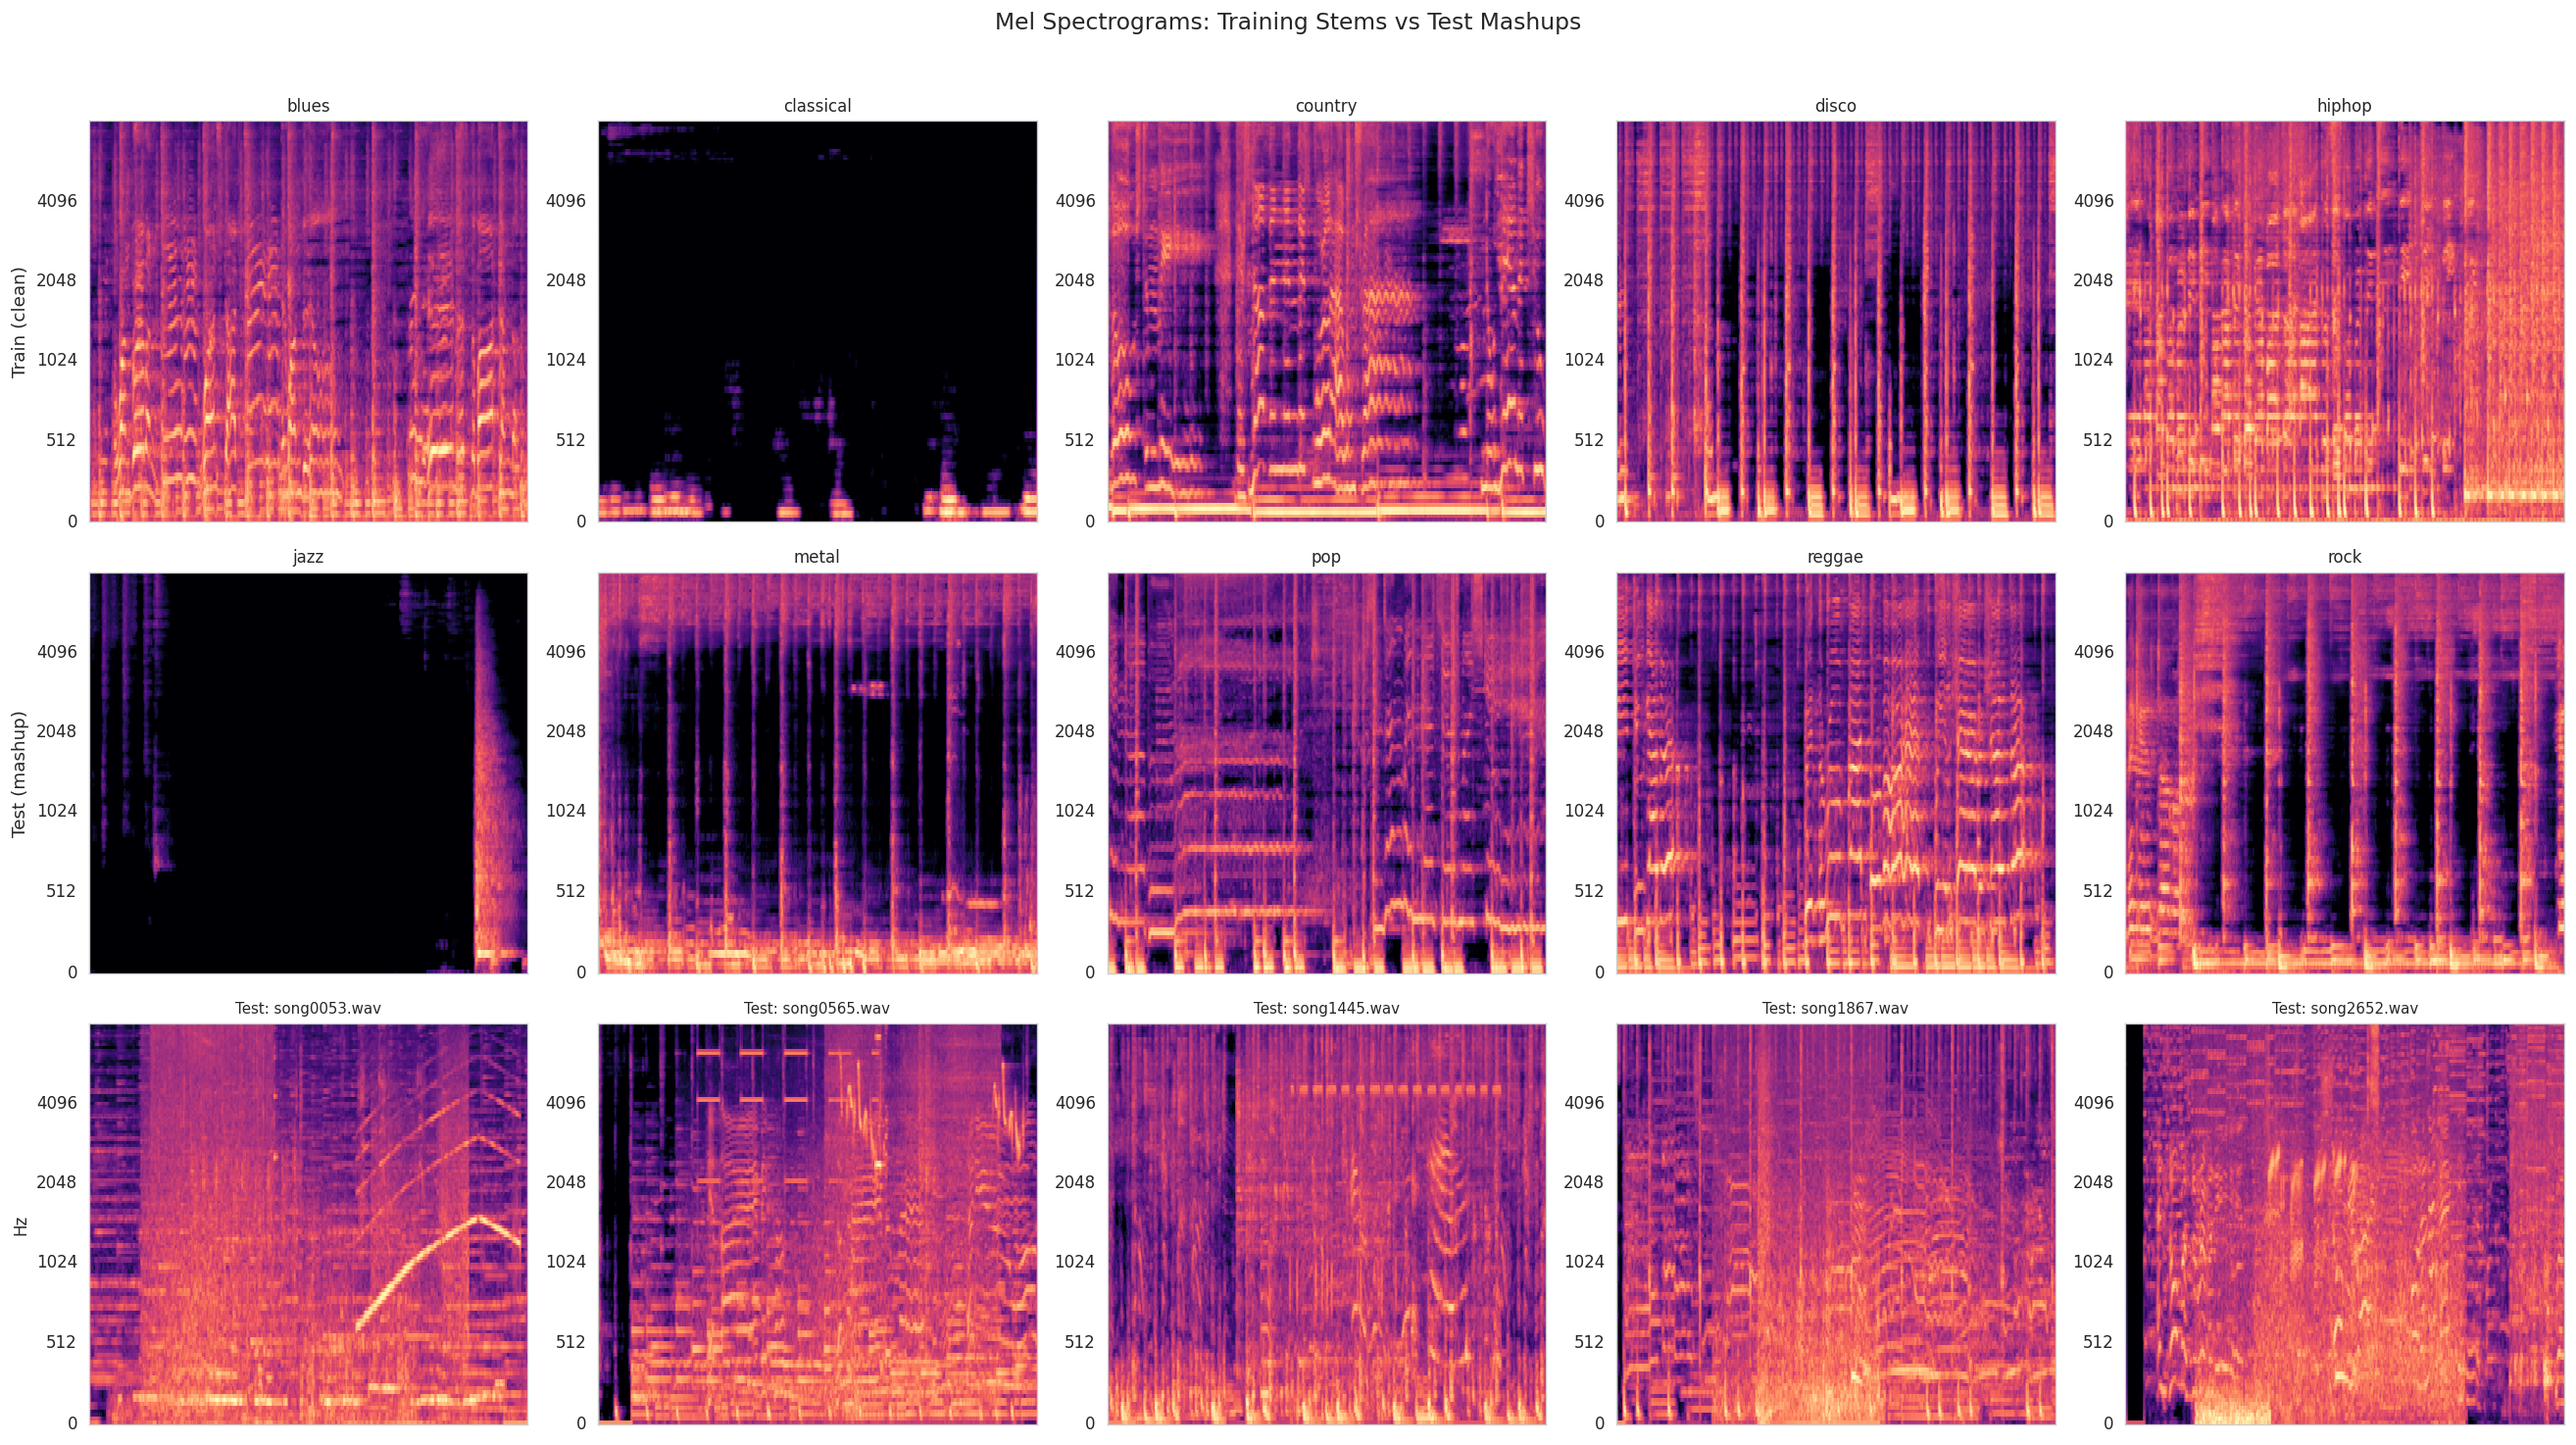

Visual domain shift: test mashups are denser, noisier, with overlapping frequency content.


In [11]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))

# Row 1-2: One song per genre (mixed stems)
for idx, genre in enumerate(GENRES):
    ax = axes[idx // 5][idx % 5]
    gp = os.path.join(STEMS_DIR, genre)
    song = sorted(os.listdir(gp))[0]
    stems_y = []
    for st in ['drums', 'vocals', 'bass']:
        fp = os.path.join(gp, song, f"{st}.wav")
        if os.path.exists(fp):
            y, _ = librosa.load(fp, sr=SR, duration=10.0)
            stems_y.append(y)
    if stems_y:
        mx = max(len(s) for s in stems_y)
        mix = np.zeros(mx)
        for s in stems_y: mix[:len(s)] += s
        peak = np.max(np.abs(mix))
        if peak > 0: mix /= peak
        S = librosa.feature.melspectrogram(y=mix, sr=SR, n_mels=128, fmax=8000)
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=SR, ax=ax, y_axis='mel', fmax=8000)
    ax.set_title(genre, fontsize=10)
    if idx > 0: ax.set_ylabel('')

# Row 2: Test mashups
test_sample = random.sample(glob.glob(os.path.join(TEST_DIR, '*.wav')), 5)
for idx, tf in enumerate(sorted(test_sample)):
    ax = axes[2][idx]
    y, _ = librosa.load(tf, sr=SR, duration=10.0)
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128, fmax=8000)
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=SR, ax=ax, y_axis='mel', fmax=8000)
    ax.set_title(f'Test: {os.path.basename(tf)[:15]}', fontsize=9)
    if idx > 0: ax.set_ylabel('')

axes[0][0].set_ylabel('Train (clean)', fontsize=11)
axes[1][0].set_ylabel('Test (mashup)', fontsize=11)
plt.suptitle('Mel Spectrograms: Training Stems vs Test Mashups', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('mel_spectrograms.png', bbox_inches='tight')
plt.show()
print("Visual domain shift: test mashups are denser, noisier, with overlapping frequency content.")

## 7. Train vs Test Distribution Shift
The core challenge — training on clean stems, testing on noisy mashups.

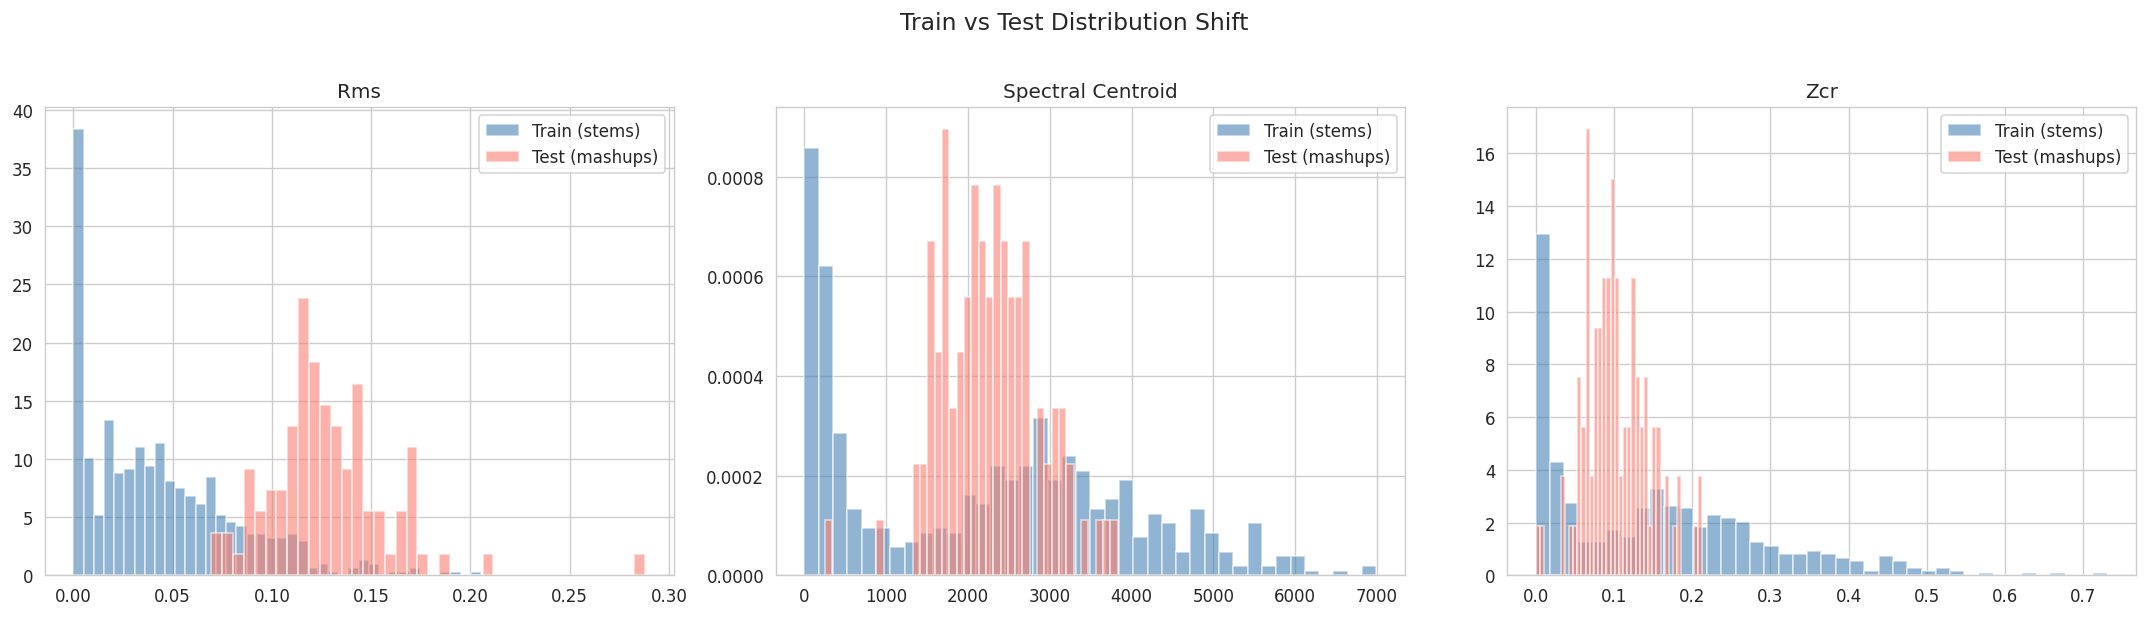

Test mashups are louder (higher RMS), denser (higher spectral centroid), confirming distribution shift.


In [12]:
# Compute stats for test samples
test_stats = []
for tf in random.sample(glob.glob(os.path.join(TEST_DIR, '*.wav')), 100):
    y, _ = librosa.load(tf, sr=SR, duration=10.0)
    test_stats.append({
        'rms': float(np.mean(librosa.feature.rms(y=y))),
        'spectral_centroid': float(np.mean(librosa.feature.spectral_centroid(y=y, sr=SR))),
        'zcr': float(np.mean(librosa.feature.zero_crossing_rate(y)))
    })
test_df = pd.DataFrame(test_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['rms', 'spectral_centroid', 'zcr']):
    axes[i].hist(stats_df[col], bins=40, alpha=0.6, density=True, label='Train (stems)', color='steelblue')
    axes[i].hist(test_df[col], bins=40, alpha=0.6, density=True, label='Test (mashups)', color='salmon')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend()
plt.suptitle('Train vs Test Distribution Shift', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('distribution_shift.png', bbox_inches='tight')
plt.show()
print("Test mashups are louder (higher RMS), denser (higher spectral centroid), confirming distribution shift.")

## 8. ESC-50 Noise Categories

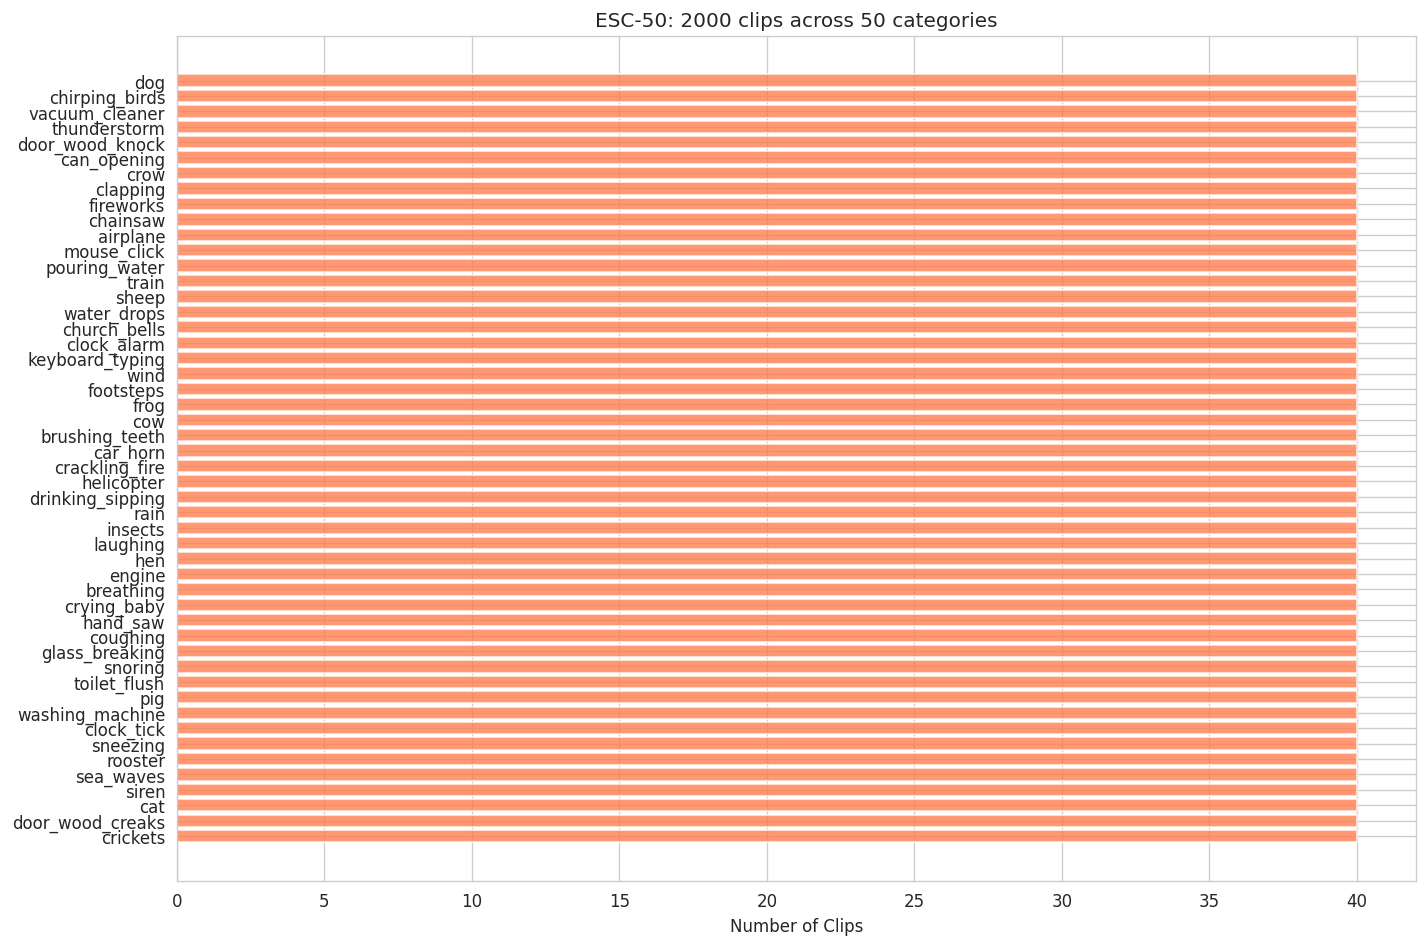

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
cat_counts = esc_meta['category'].value_counts()
ax.barh(cat_counts.index, cat_counts.values, color='coral', alpha=0.8)
ax.set_xlabel('Number of Clips')
ax.set_title(f'ESC-50: {len(esc_meta)} clips across {esc_meta["category"].nunique()} categories')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('esc50_categories.png', bbox_inches='tight')
plt.show()

## 9. Key Findings

| Finding | Implication |
|---------|-------------|
| `others` stem missing for all 1000 songs | Data loader must work with 3 stems only |
| Classical/Jazz have very low RMS (~0.003) | Model needs volume-invariant normalization |
| Significant train↔test distribution shift | Must simulate mashups during training |
| Test mashups are louder, denser, noisier | Need ESC-50 noise injection + overdrive augmentation |
| 10 balanced classes (100 songs each) | No class imbalance issues |
| ESC-50 provides 2000 noise clips (50 categories) | Rich noise augmentation source |

**Conclusion:** The main challenge is **domain shift** — training on clean separated stems but testing on noisy mashups. Success depends on synthetic mashup generation that matches test distribution.